# Unified RS-FFF checkpoint diagnostics

This notebook evaluates a staged unified checkpoint. Change `CHECKPOINT` in the setup cell to regenerate every plot for another run. The default target is the new charge-transfer-stage model in `checkpoints/water_staged_ct`.

The figures cover:

- correlation plots for each fitted energy component, monomer deformation energy, and total binding energy
- molecular polarizability, dipole, and quadrupole moment correlations on the monomer anchor
- predicted atom/pair parameter distributions
- predicted many-body contributions for each energy term
- force correlation for the total-energy gradient

In [24]:
%matplotlib inline

import os
import sys
from pathlib import Path
from types import SimpleNamespace

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import torch

# Resolve the repository root no matter where Jupyter starts the kernel.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from rsfff.ff.many_body import mbe_dataset
from rsfff.ff.molecular_multipoles import fragment_multipoles, reference_multipoles
from rsfff.ff.multipole import spherical_to_cartesian_quadrupole
from rsfff.ff.units import BOHR_ANG, KJMOL_PER_HARTREE
from rsfff.mlip.reference_states import AtomicStateReference
from rsfff.train.config import load_config, stage_config
from rsfff.train.data import load_datasets, load_extxyz, load_reference_energies
from rsfff.train.loss import compute_forces
from rsfff.train.train_eem import resolve_device
from rsfff.train.train_unified import build_unified_model

In [25]:
# ---- Regeneration knobs ---------------------------------------------------------------
CHECKPOINT = "checkpoints/water_staged_ct/best.pt"
CONFIG = "configs/water_staged.yaml"
STAGE = "auto"                  # "auto", "frozen", "pol", "ct", or None
DEVICE = "cpu"                  # CPU is stable for float64 plots; use "auto" if desired.
EVAL_SPLIT = "all"              # "all" or "validation"; validation is per-file here.
MAX_FRAMES_PER_CLUSTER = None    # e.g. 200 for quick iteration
BATCH_SIZE = 64
FORCE_FRAMES_PER_CLUSTER = 40    # forces need autograd; keep this modest for interactivity.
PARAMETER_FRAMES_PER_CLUSTER = 120
MBE_PER_CLUSTER = 40             # strongest frames per w3/w4/w5 cluster for MBE plots.
MBE_SORT_KEY = "int"
ISOLATED_SPECIES_REFERENCE = "data/isolated_species_wb97mv.extxyz"
REFERENCE_SPECIES = "H2O"
FIGDIR = Path("notebooks/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

ENERGY_TERMS = [
    ("onebody", "fragment_energy", "monomer deformation energy"),
    ("elst", "cls_elec", "frozen electrostatics"),
    ("pauli", "mod_pauli", "Pauli repulsion"),
    ("disp", "disp", "dispersion"),
    ("pol", "pol", "polarization"),
    ("ct", "ct", "charge transfer"),
    ("total", "energy", "binding energy"),
]

PALETTE = {
    "w2": "#276ef1",
    "w3": "#1b998b",
    "w4": "#db6d00",
    "w5": "#7a4cc2",
}
ELEMENT = {1: "H", 8: "O"}
ELEMENT_COLOR = {1: "#276ef1", 8: "#d64545"}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e8ef",
    "grid.linewidth": 0.7,
    "axes.labelcolor": "#20242c",
    "axes.edgecolor": "#aeb4c0",
    "xtick.color": "#3c4450",
    "ytick.color": "#3c4450",
    "font.size": 9,
})

In [26]:
def torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def infer_stage_name(checkpoint, cfg):
    if STAGE not in ("auto", None):
        return STAGE
    if STAGE is None or not cfg.stages:
        return None
    run_dir = Path(checkpoint).parent.name
    prefix = f"{cfg.run_name}_"
    if run_dir.startswith(prefix):
        candidate = run_dir[len(prefix):]
        if candidate in {s.name for s in cfg.stages}:
            return candidate
    return cfg.stages[-1].name


def staged_config_for_checkpoint(config_path, checkpoint):
    cfg = load_config(config_path)
    name = infer_stage_name(checkpoint, cfg)
    if name is None:
        return cfg, None
    matches = [s for s in cfg.stages if s.name == name]
    if not matches:
        raise ValueError(f"stage {name!r} is not in {config_path}; available {[s.name for s in cfg.stages]}")
    return stage_config(cfg, matches[0]), name


def load_unified_checkpoint(checkpoint=CHECKPOINT, config=CONFIG, device=DEVICE):
    cfg, stage_name = staged_config_for_checkpoint(config, checkpoint)
    torch.set_default_dtype(torch.float64 if cfg.dtype == "float64" else torch.float32)
    state = torch_load(checkpoint)
    neighbor_types = state.get("neighbor_types")
    if neighbor_types is None:
        probe = load_datasets(cfg.data.path, dtype=torch.get_default_dtype())
        neighbor_types = probe.unique_atomic_numbers
    reference_energies = load_reference_energies(cfg.data.reference_energies, neighbor_types).to(torch.get_default_dtype())
    atomic_states = None
    if cfg.data.atomic_reference_states:
        atomic_states = AtomicStateReference.from_json(
            cfg.data.atomic_reference_states,
            neighbor_types,
            dtype=torch.get_default_dtype(),
        )
    model = build_unified_model(cfg, neighbor_types, reference_energies, atomic_states)
    model.load_state_dict(state["model_state"])
    model.eval()
    resolved = torch.device("cpu" if device == "cpu" else resolve_device(device, cfg.dtype))
    model.to(resolved)
    return model, cfg, state, stage_name, resolved


def cluster_tag(path):
    name = Path(path).name
    for token in name.replace("-", "_").split("_"):
        if token.startswith("w") and token[1:].isdigit():
            return token
    return Path(path).stem


def load_cluster_datasets(cfg):
    paths = cfg.data.path if isinstance(cfg.data.path, list) else [cfg.data.path]
    dtype = torch.float64 if cfg.dtype == "float64" else torch.float32
    return {cluster_tag(p): load_extxyz(p, dtype=dtype) for p in paths}


def reference_species_energy(path=ISOLATED_SPECIES_REFERENCE, species=REFERENCE_SPECIES):
    from ase.io import iread

    for atoms in iread(str(path), index=":"):
        if atoms.info.get("name") == species:
            return float(atoms.get_potential_energy())
    raise ValueError(f"no frame named {species!r} in {path}")


def frame_indices(dataset, cfg):
    n = len(dataset)
    idx = np.arange(n)
    if EVAL_SPLIT == "validation":
        rng = np.random.default_rng(cfg.data.seed)
        perm = rng.permutation(n)
        n_val = max(1, int(round(n * cfg.data.holdout_fraction)))
        idx = np.sort(perm[:n_val])
    elif EVAL_SPLIT != "all":
        raise ValueError("EVAL_SPLIT must be 'all' or 'validation'")
    if MAX_FRAMES_PER_CLUSTER is not None:
        idx = idx[:MAX_FRAMES_PER_CLUSTER]
    return idx.tolist()


def to_np(x):
    return x.detach().cpu().numpy()


def fragment_to_system(batch):
    if batch.fragment_to_batch is not None:
        return batch.fragment_to_batch
    f2b = batch.batch_idx.new_zeros(batch.n_fragments)
    return f2b.scatter_(0, batch.fragment_idx, batch.batch_idx)


def pool_fragments_to_frames(values, batch):
    f2b = fragment_to_system(batch)
    return values.new_zeros(batch.n_systems).index_add_(0, f2b, values)

In [27]:
model, cfg, state, stage_name, device = load_unified_checkpoint()
datasets = load_cluster_datasets(cfg)
anchor = load_extxyz(cfg.data.monomer_path, dtype=torch.get_default_dtype()) if cfg.data.monomer_path else None
h2o_reference_energy = reference_species_energy()

print(f"checkpoint: {CHECKPOINT}")
print(f"stage: {stage_name or 'single'}")
print(f"epoch: {state.get('epoch', 'unknown')}    val_loss: {state.get('val_loss', float('nan')):.6g}")
print(f"device: {device}    dtype: {cfg.dtype}")
print(f"{REFERENCE_SPECIES} reference: {h2o_reference_energy:.12f} Ha from {ISOLATED_SPECIES_REFERENCE}")
print("datasets:", {tag: len(ds) for tag, ds in datasets.items()})
if anchor is not None:
    print(f"monomer anchor: {len(anchor)} frames from {cfg.data.monomer_path}")

checkpoint: checkpoints/water_staged_ct/best.pt
stage: ct
epoch: 45    val_loss: 105.44
device: cpu    dtype: float64
H2O reference: -76.433473067589 Ha from data/isolated_species_wb97mv.extxyz
datasets: {'w2': 2398, 'w3': 2392, 'w4': 2395, 'w5': 2394}
monomer anchor: 499 frames from data/wb97mv_tzvpd/h2o_wb97mv_tzvpd_pol.xyz


In [28]:
def fragments_per_frame(batch):
    f2b = fragment_to_system(batch)
    return torch.bincount(f2b, minlength=batch.n_systems).to(batch.positions.dtype)


def collect_energy_predictions(model, datasets, cfg, device, monomer_ref_energy, batch_size=BATCH_SIZE):
    rows = {term: {"ref": [], "pred": [], "tag": []} for term, _, _ in ENERGY_TERMS}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)

            for term, target, _label in ENERGY_TERMS:
                if term == "total":
                    n_frag = fragments_per_frame(batch)
                    pred = out.energy - monomer_ref_energy * n_frag
                    ref = batch.energy - monomer_ref_energy * n_frag
                elif term == "onebody":
                    if batch.fragment_energy is None:
                        continue
                    pred = pool_fragments_to_frames(out.fragment_energy - monomer_ref_energy, batch)
                    ref = pool_fragments_to_frames(batch.fragment_energy - monomer_ref_energy, batch)
                else:
                    if term not in out.interaction or batch.eda is None or target not in batch.eda:
                        continue
                    pred = out.interaction[term]
                    ref = batch.eda[target]
                rows[term]["pred"].append(to_np(pred) * KJMOL_PER_HARTREE)
                rows[term]["ref"].append(to_np(ref) * KJMOL_PER_HARTREE)
                rows[term]["tag"].extend([tag] * len(pred))
    packed = {}
    for term, data in rows.items():
        if data["pred"]:
            packed[term] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "tag": np.asarray(data["tag"]),
            }
    return packed


def metrics(ref, pred):
    err = pred - ref
    if len(ref) > 1 and np.std(ref) > 0 and np.std(pred) > 0:
        r2 = float(np.corrcoef(ref, pred)[0, 1] ** 2)
    else:
        r2 = np.nan
    return float(np.abs(err).mean()), float(np.sqrt(np.mean(err ** 2))), r2


energy = collect_energy_predictions(model, datasets, cfg, device, h2o_reference_energy)
print(f"{'term':<12}{'n':>8}{'MAE':>12}{'RMSE':>12}{'R2':>10}")
for term, _target, label in ENERGY_TERMS:
    if term not in energy:
        continue
    mae, rmse, r2 = metrics(energy[term]["ref"], energy[term]["pred"])
    print(f"{term:<12}{len(energy[term]['ref']):>8}{mae:>12.4f}{rmse:>12.4f}{r2:>10.5f}  {label}")

term               n         MAE        RMSE        R2
onebody         9579      2.2786      2.3988   0.99378  monomer deformation energy
elst            9579      0.5765      0.7737   0.99975  frozen electrostatics
pauli           9579      0.3833      0.5369   0.99996  Pauli repulsion
disp            9579      0.1262      0.1666   0.99981  dispersion
pol             9579      0.3629      0.5254   0.99821  polarization
ct              9579      0.3646      0.5272   0.99848  charge transfer
total           9579      1.6831      1.9642   0.99700  binding energy


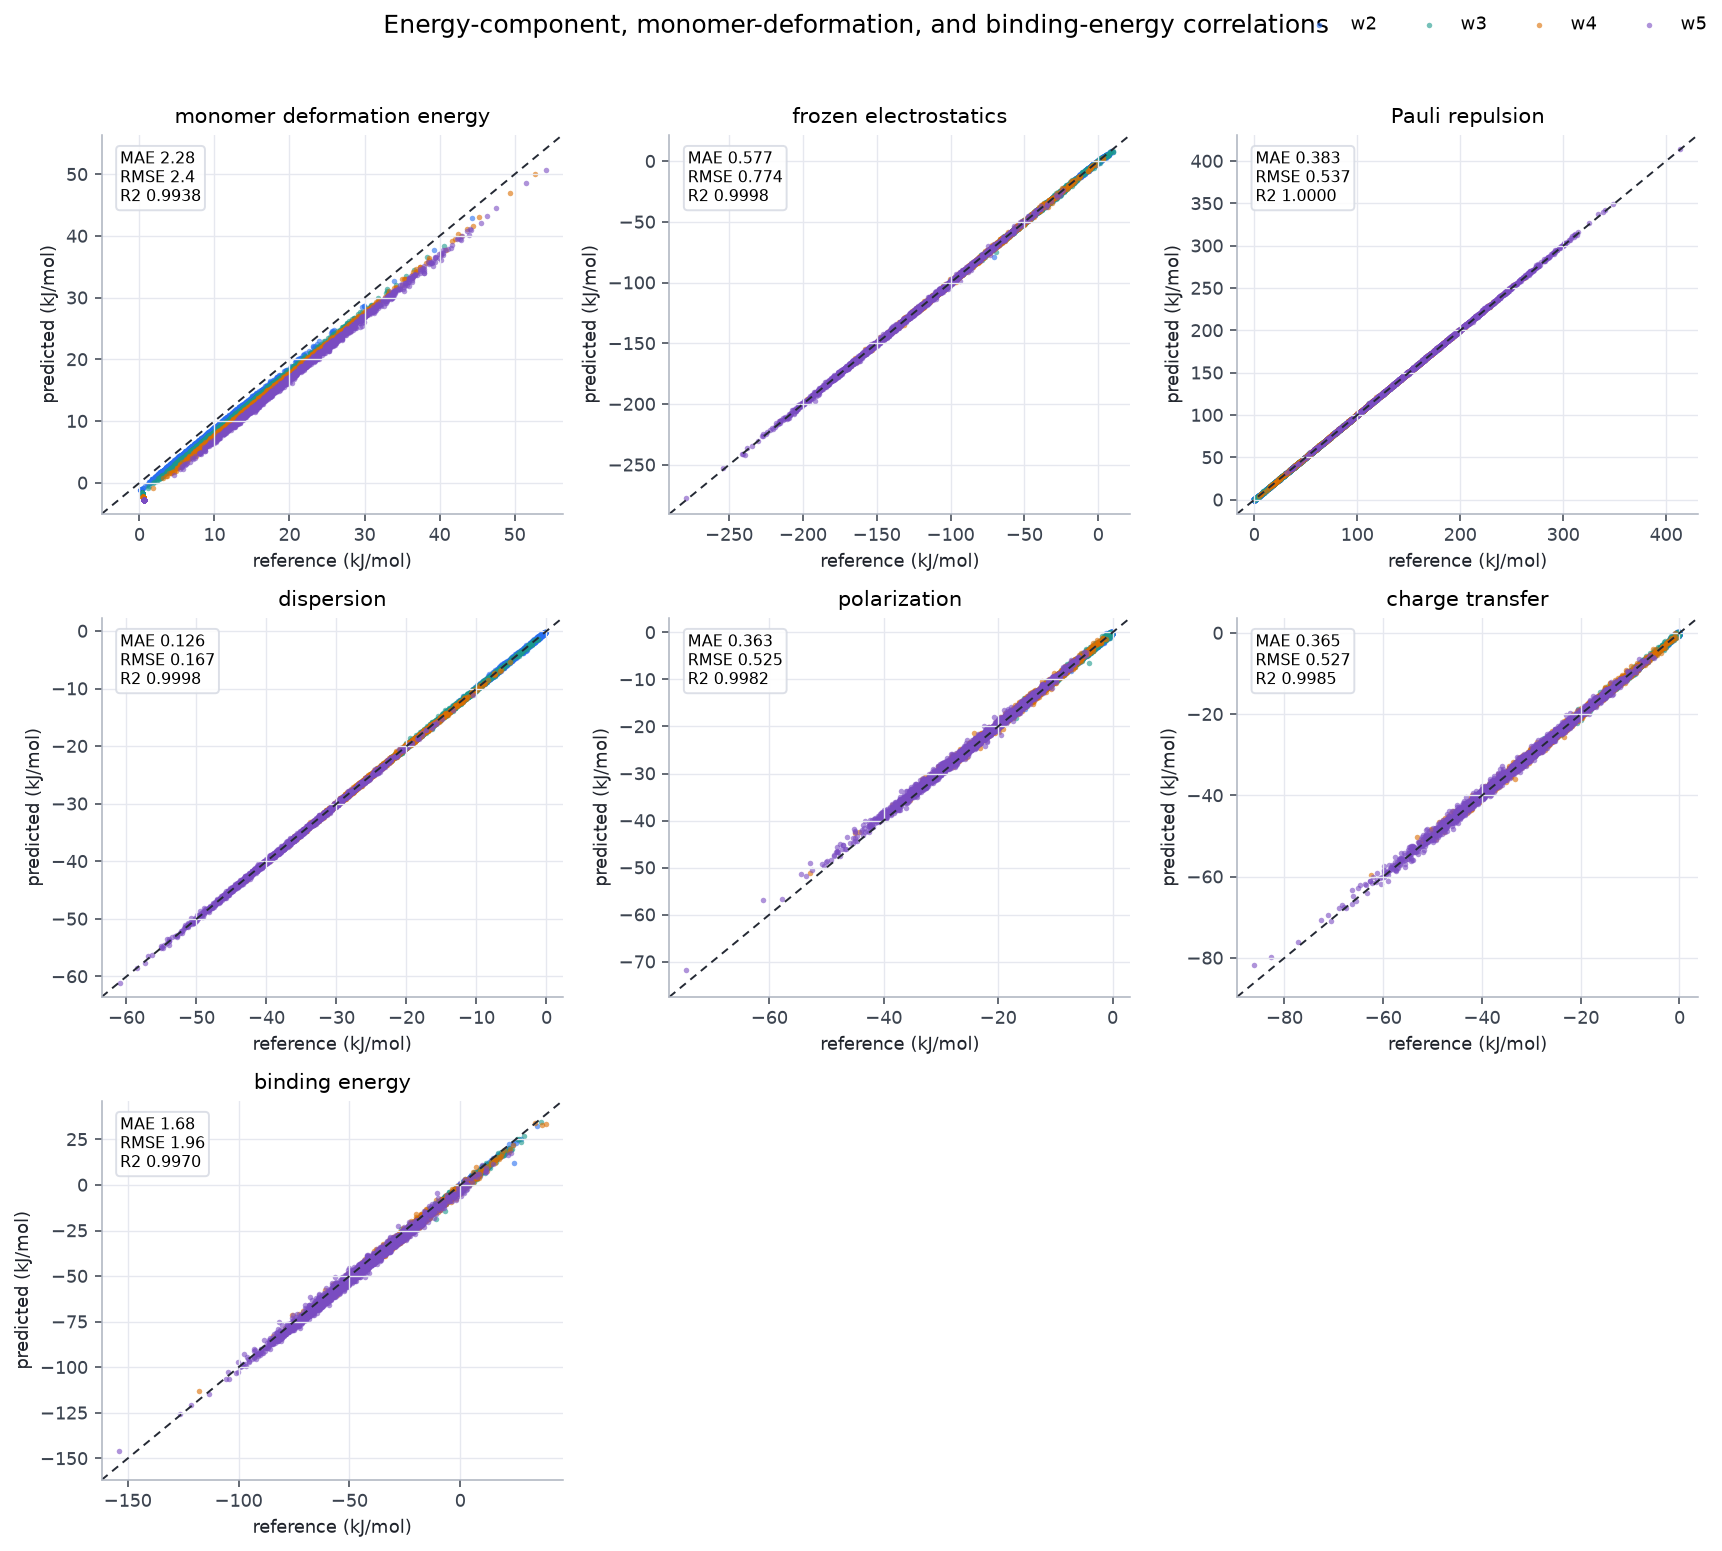

In [29]:
def plot_parity_grid(data, labels, *, title, unit, path=None, ncols=3):
    keys = [k for k, _ in labels if k in data]
    nrows = int(np.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.6 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, key in zip(axes.ravel(), keys):
        ax.set_visible(True)
        d = data[key]
        ref, pred, tags = d["ref"], d["pred"], d.get("tag")
        lo = min(np.min(ref), np.min(pred))
        hi = max(np.max(ref), np.max(pred))
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0, ls=(0, (4, 3)))
        if tags is None:
            ax.scatter(ref, pred, s=8, alpha=0.65, lw=0, color="#276ef1")
        else:
            for tag in sorted(set(tags)):
                m = tags == tag
                ax.scatter(ref[m], pred[m], s=8, alpha=0.6, lw=0, color=PALETTE.get(tag, "#555"), label=tag)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(dict(labels)[key])
        ax.set_xlabel(f"reference ({unit})")
        ax.set_ylabel(f"predicted ({unit})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
    handles, labels_ = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_, loc="upper right", frameon=False, ncol=len(handles))
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

energy_labels = [(term, label) for term, _target, label in ENERGY_TERMS]
fig = plot_parity_grid(
    energy,
    energy_labels,
    title="Energy-component, monomer-deformation, and binding-energy correlations",
    unit="kJ/mol",
    path=FIGDIR / "water_staged_ct_energy_correlations.png",
)
plt.show()

In [30]:
def collect_response_properties(model, anchor, device, batch_size=BATCH_SIZE):
    if anchor is None:
        raise ValueError("cfg.data.monomer_path is not set, so no polarizability/multipole anchor is available")
    chunks = {
        "polarizability": {"ref": [], "pred": [], "component": []},
        "dipole": {"ref": [], "pred": [], "component": []},
        "quadrupole": {"ref": [], "pred": [], "component": []},
    }
    tri = np.triu_indices(3)
    alpha_labels = np.array(["xx", "xy", "xz", "yy", "yz", "zz"])
    dip_labels = np.array(["x", "y", "z"])
    quad_labels = alpha_labels

    for start in range(0, len(anchor), batch_size):
        batch = anchor.flat_batch(range(start, min(start + batch_size, len(anchor)))).to(device)
        with torch.no_grad():
            out = model(batch, with_polarizability=True)
        if out.polarizability is not None and batch.polarizability is not None:
            pred_a = to_np(out.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            ref_a = to_np(batch.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            chunks["polarizability"]["pred"].append(pred_a.ravel())
            chunks["polarizability"]["ref"].append(ref_a.ravel())
            chunks["polarizability"]["component"].extend(np.tile(alpha_labels, pred_a.shape[0]))

        if batch.fragment_dipole is not None and batch.fragment_second_moment is not None:
            quad_c = None if out.quad_s is None else spherical_to_cartesian_quadrupole(out.quad_s)
            frag_q = batch.fragment_charge if batch.fragment_charge is not None else batch.positions.new_zeros(batch.n_fragments)
            pred_d, pred_q = fragment_multipoles(
                out.charges, batch.positions, batch.atomic_numbers, batch.fragment_idx,
                batch.n_fragments, frag_q, out.mu, quad_c,
            )
            ref_d, ref_q = reference_multipoles(
                batch.fragment_dipole, batch.fragment_second_moment, batch.positions,
                batch.atomic_numbers, batch.fragment_idx, batch.n_fragments, frag_q,
            )
            pred_d, ref_d = to_np(pred_d), to_np(ref_d)
            pred_q, ref_q = to_np(pred_q)[:, tri[0], tri[1]], to_np(ref_q)[:, tri[0], tri[1]]
            chunks["dipole"]["pred"].append(pred_d.ravel())
            chunks["dipole"]["ref"].append(ref_d.ravel())
            chunks["dipole"]["component"].extend(np.tile(dip_labels, pred_d.shape[0]))
            chunks["quadrupole"]["pred"].append(pred_q.ravel())
            chunks["quadrupole"]["ref"].append(ref_q.ravel())
            chunks["quadrupole"]["component"].extend(np.tile(quad_labels, pred_q.shape[0]))

    packed = {}
    for key, data in chunks.items():
        if data["pred"]:
            packed[key] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "component": np.asarray(data["component"]),
            }
    return packed


properties = collect_response_properties(model, anchor, device) if anchor is not None else {}
for key, d in properties.items():
    mae, rmse, r2 = metrics(d["ref"], d["pred"])
    print(f"{key:<16} n={len(d['ref']):<6} MAE={mae:.5g} RMSE={rmse:.5g} R2={r2:.5f}")

polarizability   n=2994   MAE=0.64315 RMSE=1.0419 R2=0.97023
dipole           n=1497   MAE=0.0098135 RMSE=0.016324 R2=0.99886
quadrupole       n=2994   MAE=0.13501 RMSE=0.21948 R2=0.99725


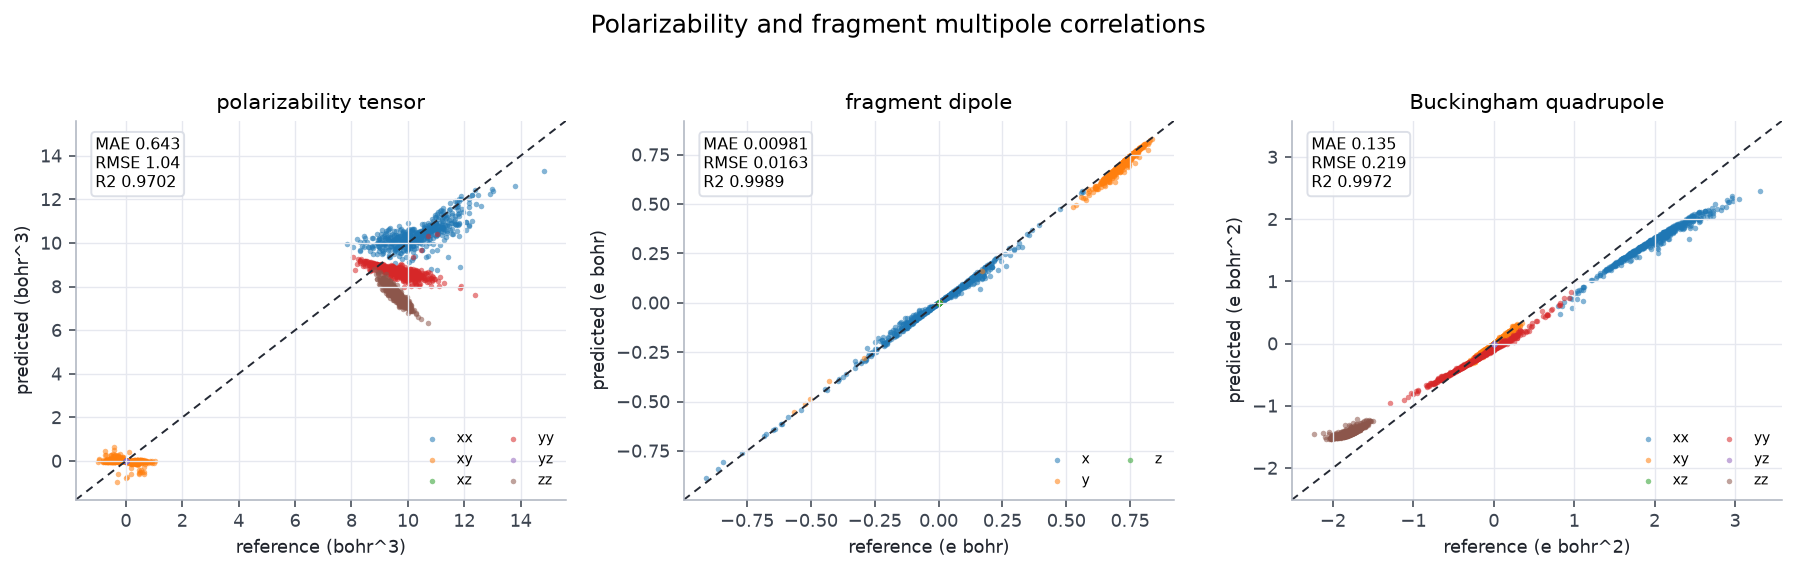

In [31]:
def plot_property_correlations(properties, path=None):
    labels = {
        "polarizability": ("polarizability tensor", "bohr^3"),
        "dipole": ("fragment dipole", "e bohr"),
        "quadrupole": ("Buckingham quadrupole", "e bohr^2"),
    }
    keys = [k for k in labels if k in properties]
    fig, axes = plt.subplots(1, len(keys), figsize=(4.3 * len(keys), 3.9), squeeze=False)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for ax, key in zip(axes.ravel(), keys):
        d = properties[key]
        ref, pred, comp = d["ref"], d["pred"], d["component"]
        lo = min(ref.min(), pred.min())
        hi = max(ref.max(), pred.max())
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
        for i, c in enumerate(sorted(set(comp))):
            m = comp == c
            ax.scatter(ref[m], pred[m], s=8, alpha=0.55, lw=0, color=colors[i % len(colors)], label=c)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(labels[key][0])
        ax.set_xlabel(f"reference ({labels[key][1]})")
        ax.set_ylabel(f"predicted ({labels[key][1]})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.legend(frameon=False, fontsize=7, ncol=2)
    fig.suptitle("Polarizability and fragment multipole correlations", y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

if properties:
    fig = plot_property_correlations(properties, path=FIGDIR / "water_staged_ct_response_property_correlations.png")
    plt.show()

In [32]:
def feature_streams(model, batch):
    frag = batch.fragment_idx
    if model.environment is None:
        h_frag = h_env = model._augment(model.featurizer(batch, frag), batch, frag)
    else:
        grouped, full = model.featurizer(batch, frag, also_ungrouped=True)
        h_frag = model._augment(grouped, batch, frag)
        h_env = model.environment(h_frag, model._augment(full, batch, frag))
    return h_frag, h_env


def collect_atom_parameters(model, datasets, device, n_frames=PARAMETER_FRAMES_PER_CLUSTER, batch_size=BATCH_SIZE):
    parts = {k: [] for k in [
        "tag", "Z", "q", "chi", "eta", "z_pen", "b_pen", "cquad", "env_norm",
        "c6", "b_disp", "q_pauli", "b_pauli", "mu_pauli", "quad_pauli",
        "r0_elst", "r0_pauli", "r0_disp",
    ]}
    scalars = {}
    for tag, ds in datasets.items():
        take = min(n_frames, len(ds))
        for start in range(0, take, batch_size):
            batch = ds.flat_batch(range(start, min(start + batch_size, take))).to(device)
            with torch.no_grad():
                out = model(batch)
                h_frag, h_env = feature_streams(model, batch)
                c6, b_disp = model.disp_params(h_env.inv_feats, h_env.species_idx)
                q_p, b_p, mu_p, quad_p = model.pauli_params(
                    h_env.inv_feats, h_env.species_idx, h_env.vec_feats, h_env.equiv_feats
                )
                r0, alpha = model.range_heads(h_env.inv_feats, h_env.species_idx)
            n = len(batch.atomic_numbers)
            parts["tag"].extend([tag] * n)
            parts["Z"].append(to_np(batch.atomic_numbers))
            parts["q"].append(to_np(out.response.charges))
            parts["chi"].append(to_np(out.response.chi))
            parts["eta"].append(to_np(out.response.eta))
            parts["z_pen"].append(to_np(out.response.z))
            parts["b_pen"].append(to_np(out.response.b))
            cquad = out.response.cquad
            if cquad is not None and cquad.dim() > 1:
                cquad = cquad.reshape(cquad.shape[0], -1).norm(dim=-1)
            parts["cquad"].append(to_np(cquad) if cquad is not None else np.zeros(n))
            parts["env_norm"].append(to_np(out.environment_norm) if out.environment_norm is not None else np.zeros(n))
            parts["c6"].append(to_np(c6))
            parts["b_disp"].append(to_np(b_disp))
            parts["q_pauli"].append(to_np(q_p))
            parts["b_pauli"].append(to_np(b_p))
            parts["mu_pauli"].append(to_np(mu_p.norm(dim=-1)) if mu_p is not None else np.zeros(n))
            parts["quad_pauli"].append(to_np(quad_p.norm(dim=-1)) if quad_p is not None else np.zeros(n))
            for key in ("elst", "pauli", "disp"):
                parts[f"r0_{key}"].append(to_np(r0[key]))
                scalars[f"alpha_{key}"] = float(to_np(alpha[key]))
    packed = {}
    for k, values in parts.items():
        if k == "tag":
            packed[k] = np.asarray(values)
        else:
            packed[k] = np.concatenate(values)
    packed.update(scalars)
    return packed


params = collect_atom_parameters(model, datasets, device)
print(f"parameter atoms: {len(params['Z'])}")
for key in ("alpha_elst", "alpha_pauli", "alpha_disp"):
    print(f"{key}: {params[key]:.4g} 1/A")

parameter atoms: 5040
alpha_elst: 4.254 1/A
alpha_pauli: 4.501 1/A
alpha_disp: 1.813 1/A


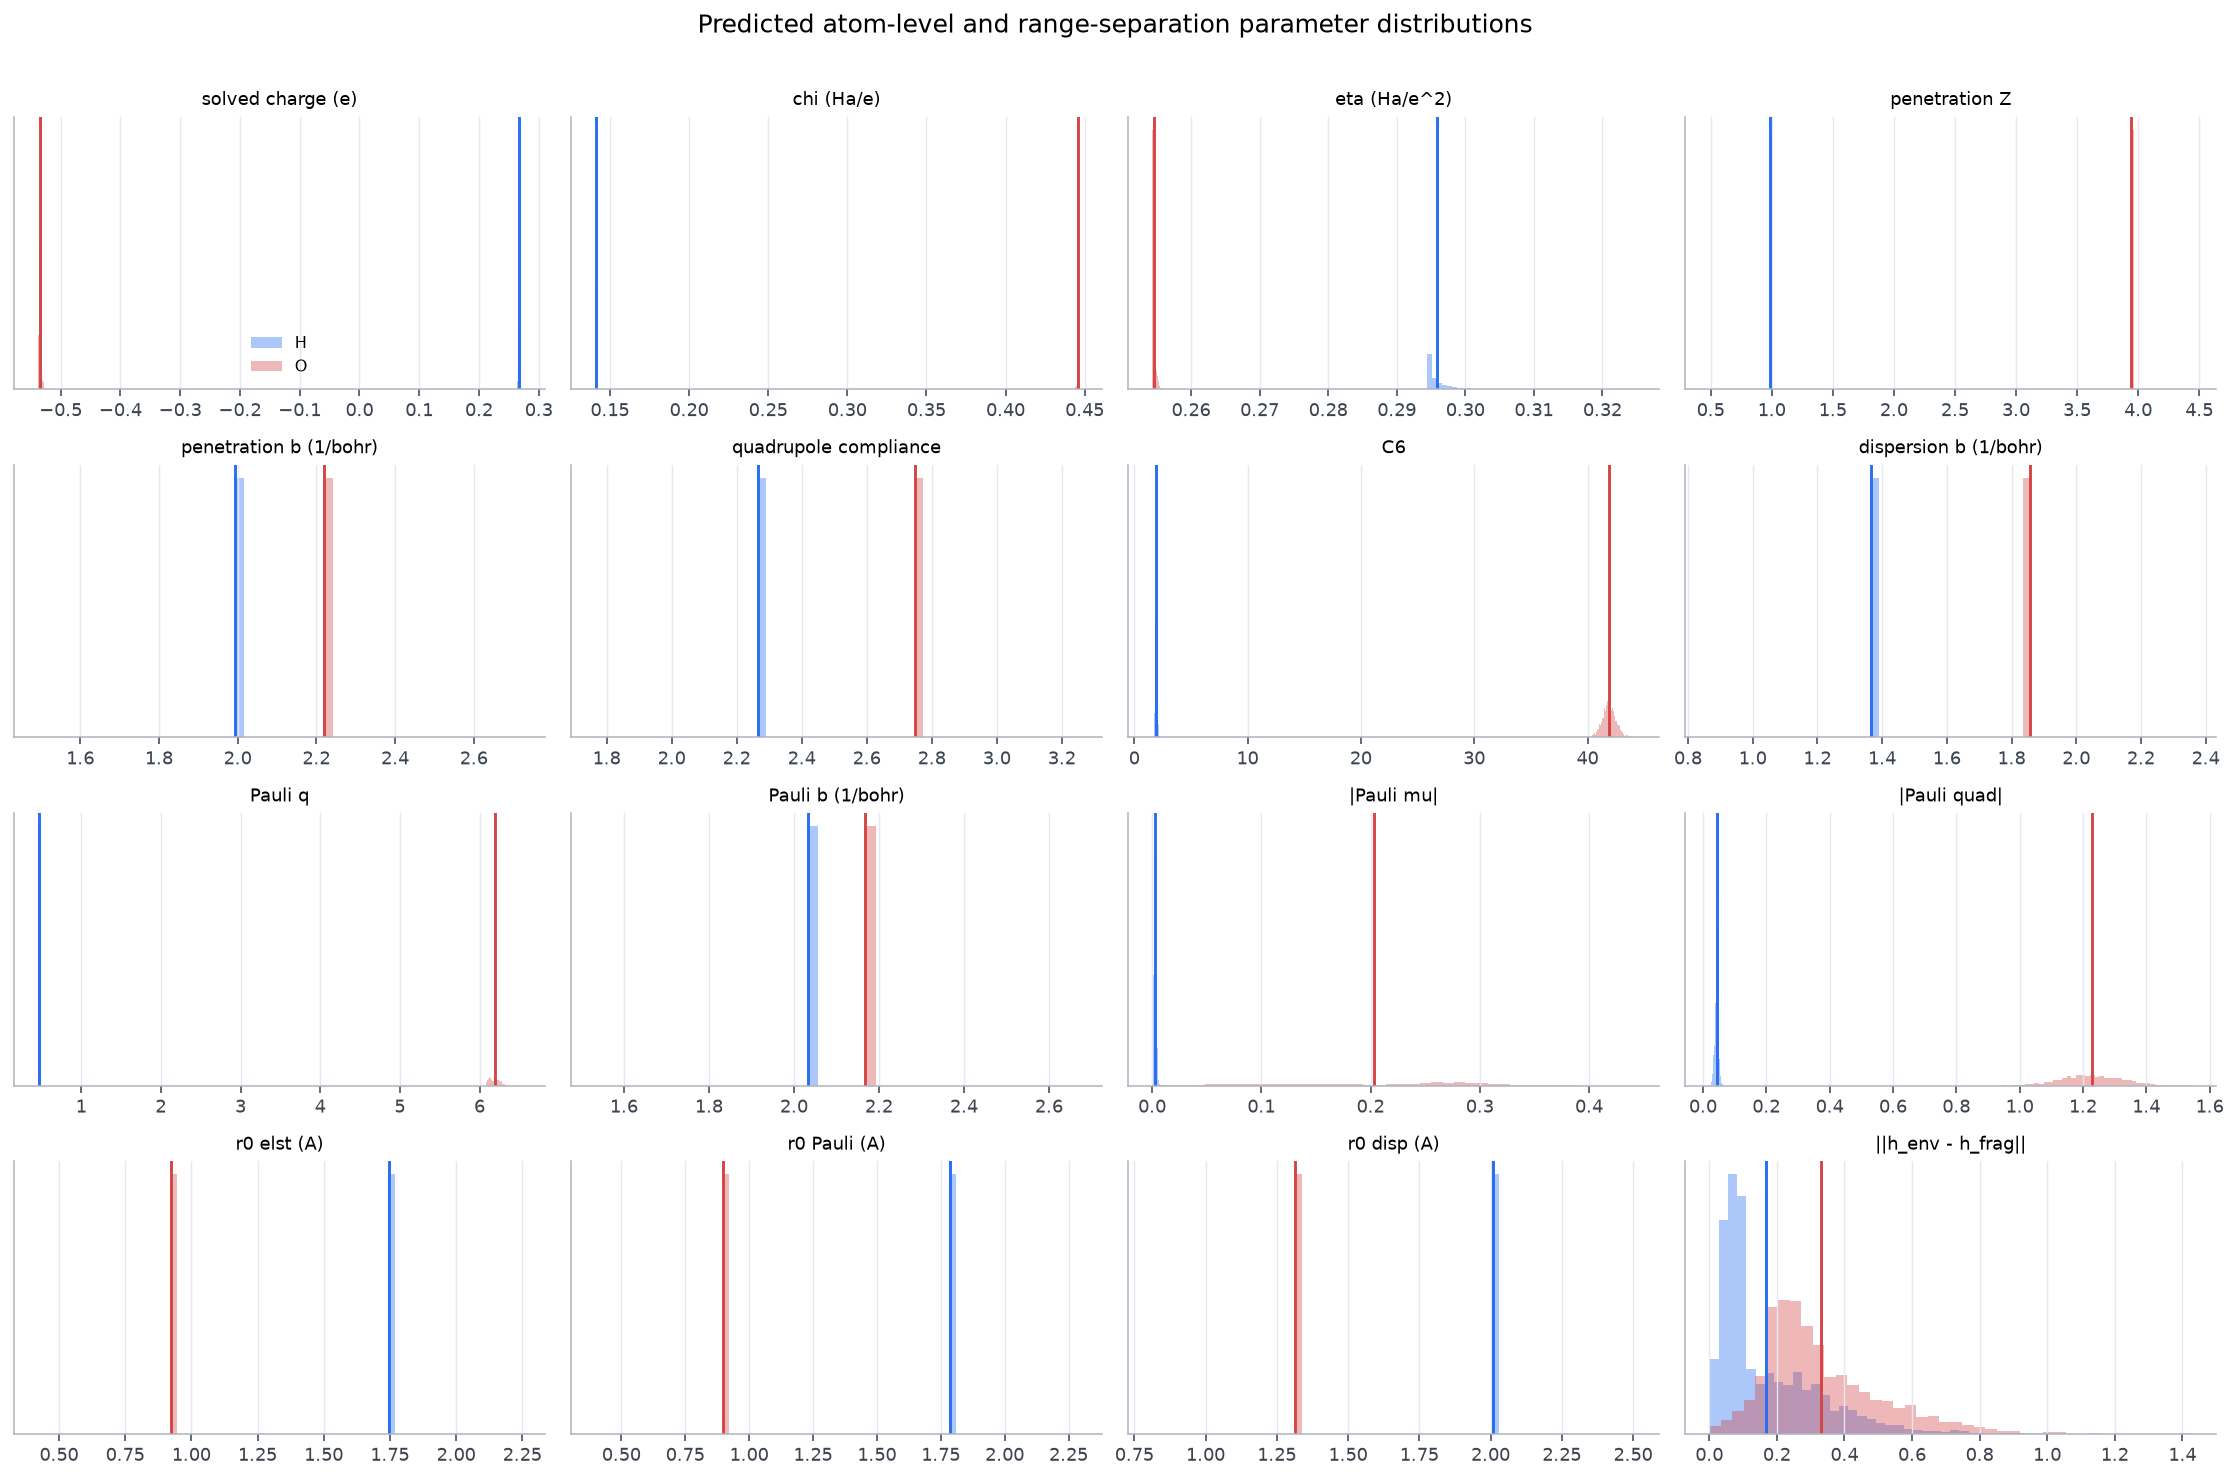

In [33]:
def plot_parameter_distributions(params, path=None):
    specs = [
        ("q", "solved charge (e)"),
        ("chi", "chi (Ha/e)"),
        ("eta", "eta (Ha/e^2)"),
        ("z_pen", "penetration Z"),
        ("b_pen", "penetration b (1/bohr)"),
        ("cquad", "quadrupole compliance"),
        ("c6", "C6"),
        ("b_disp", "dispersion b (1/bohr)"),
        ("q_pauli", "Pauli q"),
        ("b_pauli", "Pauli b (1/bohr)"),
        ("mu_pauli", "|Pauli mu|"),
        ("quad_pauli", "|Pauli quad|"),
        ("r0_elst", "r0 elst (A)"),
        ("r0_pauli", "r0 Pauli (A)"),
        ("r0_disp", "r0 disp (A)"),
        ("env_norm", "||h_env - h_frag||"),
    ]
    ncols = 4
    nrows = int(np.ceil(len(specs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.6 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, (key, label) in zip(axes.ravel(), specs):
        ax.set_visible(True)
        for z in sorted(set(params["Z"])):
            m = params["Z"] == z
            vals = params[key][m]
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=42, density=True, histtype="stepfilled", alpha=0.38,
                    color=ELEMENT_COLOR.get(int(z), "#555"), label=ELEMENT.get(int(z), str(z)))
            ax.axvline(np.mean(vals), color=ELEMENT_COLOR.get(int(z), "#555"), lw=1.5)
        ax.set_title(label, fontsize=9)
        ax.set_yticks([])
    axes.ravel()[0].legend(frameon=False, fontsize=8)
    fig.suptitle("Predicted atom-level and range-separation parameter distributions", y=1.01, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_parameter_distributions(params, path=FIGDIR / "water_staged_ct_parameter_distributions.png")
plt.show()

In [34]:
class EnergyTermModel(torch.nn.Module):
    def __init__(self, model, term):
        super().__init__()
        self.model = model
        self.term = term

    def forward(self, batch):
        out = self.model(batch)
        if self.term == "total":
            # For the MBE plot, the total binding contribution beyond pairwise is the
            # interaction sum. One-body deformation cancels only if singleton terms are
            # included; this helper's convention is E(singleton) = 0.
            energy = out.energy.new_zeros(out.energy.shape)
            for value in out.interaction.values():
                energy = energy + value
        elif self.term == "onebody":
            energy = pool_fragments_to_frames(out.fragment_energy, batch)
        else:
            energy = out.interaction[self.term]
        return SimpleNamespace(energy=energy)


def strongest_indices(dataset, n, key=MBE_SORT_KEY):
    batch = dataset.flat_batch(range(len(dataset)))
    if batch.eda is not None and key in batch.eda:
        values = to_np(batch.eda[key])
    else:
        values = to_np(batch.energy)
    return np.argsort(values)[:min(n, len(values))].tolist()


def collect_many_body_by_term(model, datasets, terms=None, per_cluster=MBE_PER_CLUSTER):
    if terms is None:
        terms = ["elst", "pauli", "disp"]
        if model.polarization:
            terms.append("pol")
        if model.charge_transfer:
            terms.append("ct")
        terms.append("total")
    rows = []
    for term in terms:
        if term != "total" and term not in model.pair_head.channels and term not in ("pol", "ct", "onebody"):
            continue
        wrapped = EnergyTermModel(model, term).to(next(model.parameters()).device)
        for tag in [t for t in ("w3", "w4", "w5") if t in datasets]:
            ds = datasets[tag]
            idx = strongest_indices(ds, per_cluster)
            res = mbe_dataset(wrapped, ds, idx, split_components=False, progress_every=0)
            k = KJMOL_PER_HARTREE
            for i in range(len(idx)):
                row = {
                    "term": term,
                    "tag": tag,
                    "n_fragments": int(res.n_fragments[i]),
                    "total": float(res.total[i]) * k,
                    "two_body": float(res.two_body[i]) * k,
                    "many_body": float(res.many_body[i]) * k,
                }
                for order in (3, 4, 5):
                    vals = res.by_order.get(order)
                    row[f"e{order}"] = float(vals[i]) * k if vals is not None else 0.0
                rows.append(row)
    return rows


mbe_rows = collect_many_body_by_term(model, datasets)
print(f"many-body rows: {len(mbe_rows)}")
for term in sorted({r['term'] for r in mbe_rows}):
    vals = np.array([r["many_body"] for r in mbe_rows if r["term"] == term])
    print(f"{term:<8} mean={vals.mean():>9.4f} kJ/mol   mean abs={np.abs(vals).mean():>9.4f}")

many-body rows: 720
ct       mean=  -2.1443 kJ/mol   mean abs=   2.1443
disp     mean=   0.3936 kJ/mol   mean abs=   0.4120
elst     mean=  -1.1086 kJ/mol   mean abs=   1.1443
pauli    mean=  -0.3694 kJ/mol   mean abs=   0.4653
pol      mean=  -7.6354 kJ/mol   mean abs=   7.6354
total    mean= -10.8641 kJ/mol   mean abs=  10.8641


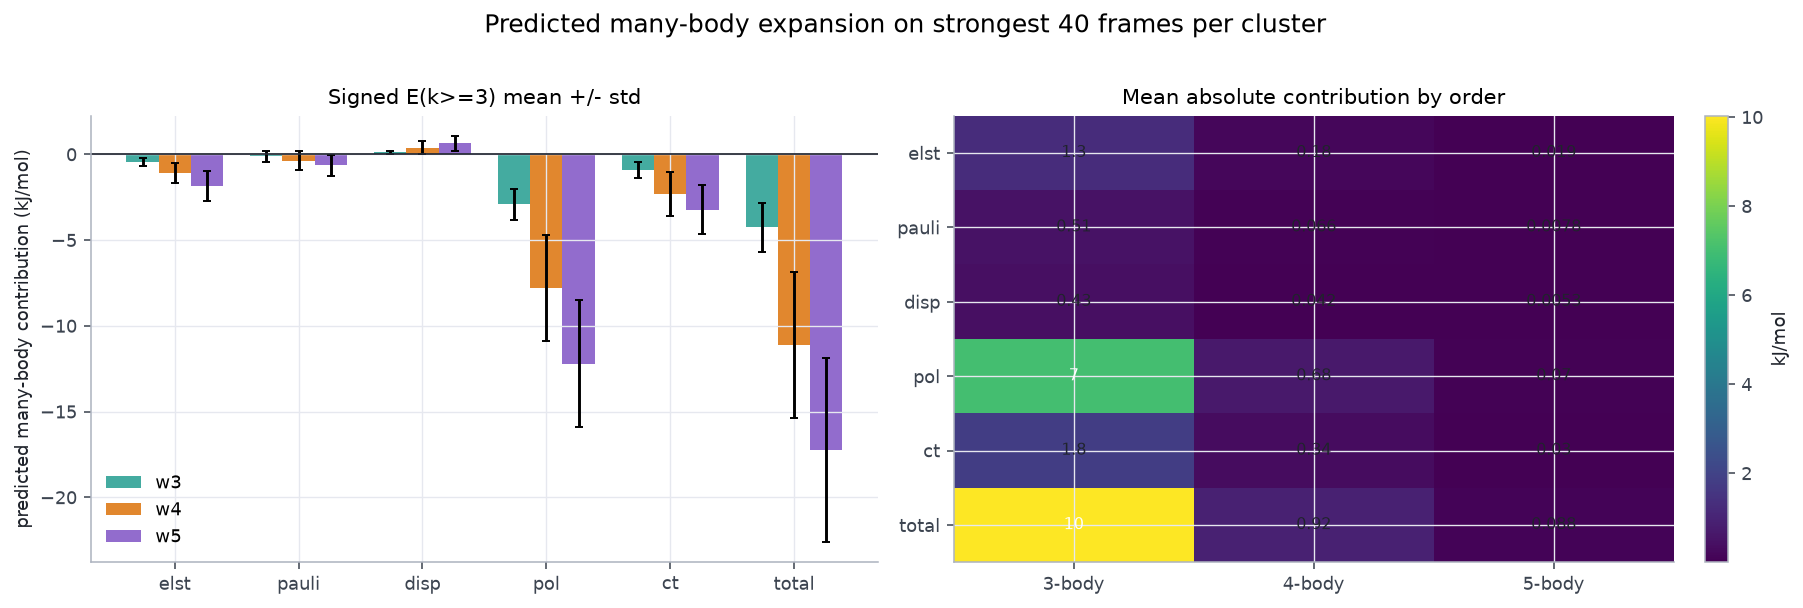

In [35]:
def plot_many_body(rows, path=None):
    terms = [t for t in ["elst", "pauli", "disp", "pol", "ct", "total"] if any(r["term"] == t for r in rows)]
    tags = [t for t in ["w3", "w4", "w5"] if any(r["tag"] == t for r in rows)]
    x = np.arange(len(terms))
    width = 0.78 / max(1, len(tags))
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2))

    ax = axes[0]
    for j, tag in enumerate(tags):
        means, stds = [], []
        for term in terms:
            vals = np.array([r["many_body"] for r in rows if r["term"] == term and r["tag"] == tag])
            means.append(np.mean(vals) if len(vals) else 0.0)
            stds.append(np.std(vals) if len(vals) else 0.0)
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, means, width=width,
               yerr=stds, capsize=2, color=PALETTE.get(tag, "#555"), alpha=0.82, label=tag)
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(terms)
    ax.set_ylabel("predicted many-body contribution (kJ/mol)")
    ax.set_title("Signed E(k>=3) mean +/- std")
    ax.legend(frameon=False)

    ax = axes[1]
    orders = ["e3", "e4", "e5"]
    image = np.zeros((len(terms), len(orders)))
    for i, term in enumerate(terms):
        for j, order in enumerate(orders):
            vals = np.array([r[order] for r in rows if r["term"] == term])
            image[i, j] = np.mean(np.abs(vals)) if len(vals) else 0.0
    im = ax.imshow(image, aspect="auto", cmap="viridis")
    ax.set_yticks(np.arange(len(terms)))
    ax.set_yticklabels(terms)
    ax.set_xticks(np.arange(len(orders)))
    ax.set_xticklabels(["3-body", "4-body", "5-body"])
    ax.set_title("Mean absolute contribution by order")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("kJ/mol")
    for i in range(len(terms)):
        for j in range(len(orders)):
            ax.text(j, i, f"{image[i, j]:.2g}", ha="center", va="center",
                    color="white" if image[i, j] > image.max() * 0.45 else "#20242c", fontsize=8)

    fig.suptitle(f"Predicted many-body expansion on strongest {MBE_PER_CLUSTER} frames per cluster", y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_many_body(mbe_rows, path=FIGDIR / "water_staged_ct_many_body_by_term.png")
plt.show()

In [36]:
def collect_force_predictions(model, datasets, cfg, device, n_frames=FORCE_FRAMES_PER_CLUSTER):
    ref_parts, pred_parts, tags = [], [], []
    for tag, ds in datasets.items():
        if not ds.has_forces:
            print(f"{tag}: no force labels; skipping")
            continue
        indices = frame_indices(ds, cfg)[:min(n_frames, len(ds))]
        for idx in indices:
            batch = ds.flat_batch([idx]).to(device)
            batch.positions.requires_grad_(True)
            out = model(batch)
            forces = compute_forces(out.energy, batch.positions, create_graph=False)
            ref = to_np(batch.forces) * KJMOL_PER_HARTREE
            pred = to_np(forces) * KJMOL_PER_HARTREE
            ref_parts.append(ref.reshape(-1))
            pred_parts.append(pred.reshape(-1))
            tags.extend([tag] * ref.size)
    return {
        "ref": np.concatenate(ref_parts),
        "pred": np.concatenate(pred_parts),
        "tag": np.asarray(tags),
    }


forces = collect_force_predictions(model, datasets, cfg, device)
mae, rmse, r2 = metrics(forces["ref"], forces["pred"])
print(f"force components: n={len(forces['ref'])}  MAE={mae:.5g}  RMSE={rmse:.5g}  R2={r2:.5f}  unit=kJ/mol/A")

force components: n=5040  MAE=5.8851  RMSE=8.8637  R2=0.98658  unit=kJ/mol/A


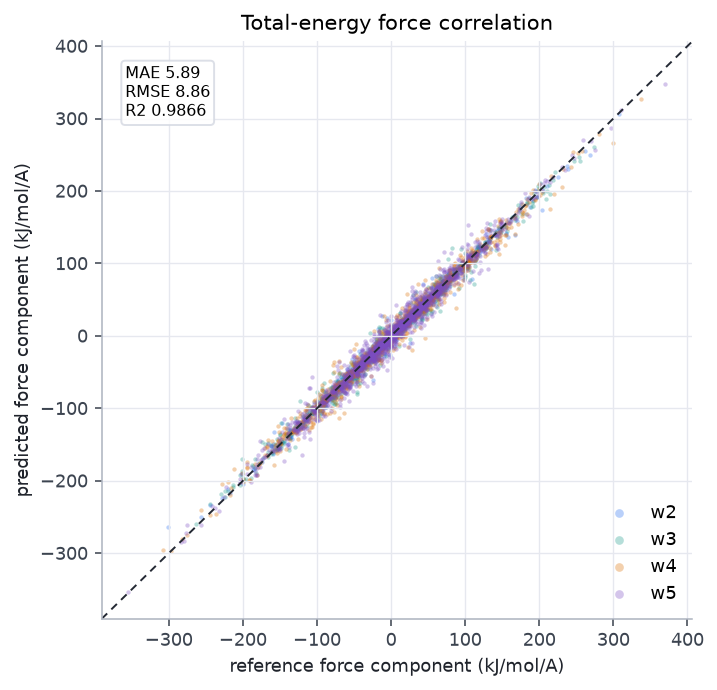

In [37]:
def plot_force_correlation(forces, path=None):
    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    ref, pred, tags = forces["ref"], forces["pred"], forces["tag"]
    lo = min(ref.min(), pred.min())
    hi = max(ref.max(), pred.max())
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
    for tag in sorted(set(tags)):
        m = tags == tag
        ax.scatter(ref[m], pred[m], s=5, alpha=0.32, lw=0, color=PALETTE.get(tag, "#555"), label=tag)
    mae, rmse, r2 = metrics(ref, pred)
    ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("reference force component (kJ/mol/A)")
    ax.set_ylabel("predicted force component (kJ/mol/A)")
    ax.set_title("Total-energy force correlation")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.legend(frameon=False, markerscale=2)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_force_correlation(forces, path=FIGDIR / "water_staged_ct_force_correlation.png")
plt.show()

## Notes

- To regenerate the same diagnostics for a different model, edit `CHECKPOINT` at the top. If the checkpoint lives in a staged run directory such as `water_staged_pol`, `STAGE = "auto"` applies the matching stage overrides from `CONFIG`.
- Monomer deformation and cluster binding energies use `REFERENCE_SPECIES` from `ISOLATED_SPECIES_REFERENCE` as the zero of energy.
- The many-body expansion can be expensive because each frame is evaluated over all fragment subsets. Increase `MBE_PER_CLUSTER` for final figures and decrease it while iterating.
- Force correlations use total-energy gradients and are intentionally sampled by `FORCE_FRAMES_PER_CLUSTER`.